In [13]:
import numpy as np
import matplotlib.pyplot as plt


Student 1: [Nina Gumbs], [6552544]
Student 2: [Luuk van Dijk], [651702]
Student 3: [Jens Groen], [6353991]

In [14]:
#Constanten
mu0 = 4*np.pi*10**-7

Magneetveld circulaire halbach array

flux_kwadraat boven, Parallel, magneten: 1.4034670675101591e-06 Wb
flux_kwadraat boven, Parallel, magneten: 1.4034670675101591e-06 Wb
flux_kwadraat boven, Halbach, magneten: 2.9129220745363327e-08 Wb
flux_kwadraat onder, Halbach, magneten: 3.363253696530069e-11 Wb


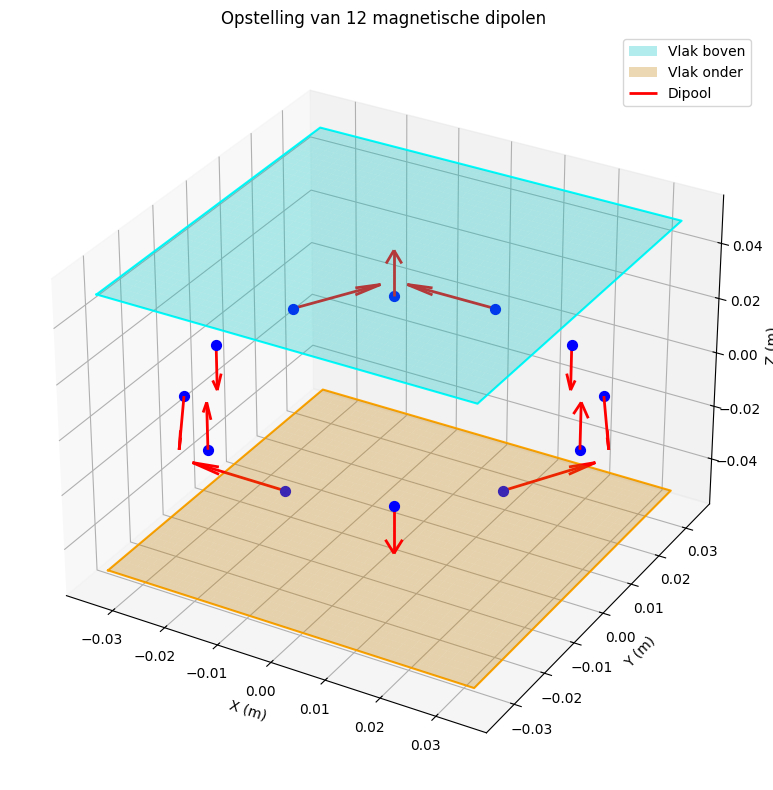

In [15]:
#########inputs#########

# aantal magneten
N = 12

# radius
r    = 0.034 

#Magneet waardes
rmag = 18*10**-3
Amag = np.pi *rmag**2
hmag =  3*10**-3
Br = 1.265 # N35 ~ N45 
p = -3 #draaingrichting en snelheid van hoek van de magneten


#Configuratie van de magneten
configuratie_namen = {
    0: "Halbach",
    1: "Parallel",
    2: "Radiaal"
}

configuratie = 0  # kies 0, 1 of 2


################flux_kwadraat################

#flux_kwadraatvlak 1
xo1 = 0
yo1 = 0
n1 = 40  # grid resolution
width1 = r*2
z_plane1 = 0.05 

#flux_kwadraatvlak 2 gespiegeld op het x-y vlak
xo2 = xo1
yo2 = yo1
n2 = n1  # grid resolution
width2 = width1
z_plane2 = -z_plane1




##############Berekeningen##########


conf = configuratie_namen[configuratie]

def m(theta,conf,p):
    V = Amag * hmag
    m = (Br * V)/mu0*Magnetenrichting(theta,conf,p)
    return m

def Magnetenrichting(theta,conf,p):
    alpha = p * theta
    z_hat = np.array([0, 0, 1]) 
    r_hat = np.array([np.cos(theta), np.sin(theta), 0])
    nu_hat = np.array([-np.sin(theta), np.cos(theta), 0])

    if conf == "Halbach":
        phi = np.sin(alpha) * nu_hat + np.cos(alpha) * z_hat 
    if conf == "Parallel":
        phi = z_hat
    if conf == "Radiaal":
        phi = r_hat
    return phi

def Magnetenpositie(r,theta):
    z = 0
    rdak = np.array([r*np.cos(theta),r*np.sin(theta),z])
    return rdak

def Bveld(r,rpunt,conf,p,N):
    Btot = np.zeros(3)
    for i in range(N):
        theta = 2*np.pi*i/N
        mag = m(theta,conf,p)
        R = rpunt - Magnetenpositie(r,theta) #vector van magneet naar meetpunt
        Rdakje = R/np.linalg.norm(R)
        B = mu0/(4*np.pi*np.linalg.norm(R)**3)*(3*np.dot(mag, Rdakje)*Rdakje - mag) 
        Btot = B + Btot
    return Btot

def maak_vlak(width, z_plane, n=50, x_offset=0, y_offset=0):
    x = np.linspace(-width/2 + x_offset, width/2 + x_offset, n)
    y = np.linspace(-width/2 + y_offset, width/2 + y_offset, n)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    punten = []
    for xi in x:
        for yi in y:
            rpunt = np.array([xi, yi, z_plane])
            punten.append((rpunt, dx, dy))
    return punten, x, y


def flux_kwadraat(meetpunten, conf, p, N):
    """Integreert Bz² over het vlak — correct voor liftkracht"""
    total = 0
    for rpunt, dx, dy in meetpunten:
        B = Bveld(r, rpunt, conf, p, N)
        total += B[2]**2 * dx * dy
    return total

# Vlak boven de magneten
vlak_boven,  x1, y1 = maak_vlak(width1, z_plane1,n1, xo1,yo1)
vlak_onder,  x2, y2 = maak_vlak(width2, z_plane2,n2, xo2, yo2)

print("flux_kwadraat boven, Parallel, magneten:", flux_kwadraat(vlak_boven,"Parallel", p,N), "Wb")
print("flux_kwadraat boven, Parallel, magneten:", flux_kwadraat(vlak_onder,"Parallel", p,N), "Wb")
print("flux_kwadraat boven, "+ conf +", magneten:", flux_kwadraat(vlak_boven,conf, p,N), "Wb")
print("flux_kwadraat onder, " + conf +  ", magneten:", flux_kwadraat(vlak_onder,conf,p,N), "Wb")




#######plotting########



def plot_vlak(ax, x, y, z_plane, color='cyan', alpha=0.3, label=''):
    """Plot het vlak in de bestaande 3D-as."""
    X, Y = np.meshgrid(x, y)
    Z = np.full_like(X, z_plane)
    ax.plot_surface(X, Y, Z, alpha=alpha, color=color, edgecolor='none', label=label)
    # Rand tekenen voor duidelijkheid
    xc = [x[0], x[-1], x[-1], x[0],  x[0]]
    yc = [y[0], y[0],  y[-1], y[-1], y[0]]
    zc = [z_plane] * 5
    ax.plot(xc, yc, zc, color=color, linewidth=1.5)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#Vlak
plot_vlak(ax, x1, y1, z_plane1, color='cyan',  label='Vlak boven')
plot_vlak(ax, x2, y2, z_plane2, color='orange', label='Vlak onder')


#magneten

for i in range(N):
    theta = 2 * np.pi * i / N
    
    pos = Magnetenpositie(r, theta)
    richting = Magnetenrichting(theta,conf,p)
    
    ax.quiver(pos[0], pos[1], pos[2],
              richting[0], richting[1], richting[2],
              length=(r/2), color='red', linewidth=2, label='Dipool' if i == 0 else "")
    
    ax.scatter(*pos, color='blue', s=50, zorder=5)



ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title(f'Opstelling van {N} magnetische dipolen')
ax.legend()
plt.tight_layout()
plt.show()


## Eddy-Current Lift Force — Afleiding

### 1. flux_kwadraat door de plaat
$$\Phi(A) = \iint_{A} B_z \, dA$$

### 2. Wet van Faraday
$$\mathcal{E} = \Phi(A) \cdot \omega$$

### 3. Weerstand van de plaat
$$R = \frac{1}{\sigma} \cdot \frac{t}{A}$$

### 4. Geïnduceerde stroom
$$I = \frac{\mathcal{E}}{R} = \frac{\sigma \cdot A \cdot \Phi(A) \cdot \omega}{t}$$

### 5. Liftkracht (Lorentz)
$$F_{lift} = I \cdot \Phi(A) = \frac{\sigma \cdot A}{t} \cdot \Phi(A)^2 \cdot \omega^2$$

### 6. Zwaartekracht
$$F_z = \rho \cdot A \cdot t \leq g$$

### 7. Levitatieconditie
$$F_{lift} > F_z$$

$$\frac{\sigma \cdot A}{t} \cdot \Phi(A)^2 \cdot \omega^2 > \rho \cdot A \cdot t \cdot g$$

### 8. Kritische hoeksnelheid
$$\boxed{\omega_{min} = \sqrt{\frac{\rho \cdot t^2 \cdot g}{\sigma \cdot \Phi(A)^2}}}$$

## $\omega_{min}$ hangt af van $\Phi(A)$ — kleine platen vangen minder flux_kwadraat op,
## dus hebben hogere $\omega$ nodig. Grote platen (groter dan het magneetpatroon) verzadigen in flux_kwadraat.

In [ ]:
# ── Constanten ───────────────────────────────────────────────
config = 1
sigma = 6e7
rho_m = 8960
g     = 9.81
t     = 0.003

# ── Parameters ───────────────────────────────────────────────
N_vals     = 12
width_vals = np.linspace(0.03, 0.5, 20)
width_cm   = width_vals * 100
n_flux_kwadraat = 30
z_plaat = np.linspace(0.05, 0.1, 10)



conf = configuratie_namen[configuratie]
# ── Figure met 2 subplots ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 10))

for Z in z_plaat:
    omega_min_vals = []
    RPM_min_vals   = []
    
    for w in width_vals:
        vlak  = maak_vlak(w, Z, n_flux_kwadraat, xo1, yo1)[0]
        Phi2  = flux_kwadraat(vlak, conf, p, N)
        A     = w**2
        Bz    = np.sqrt(Phi2 / A)
        
        if Bz > 1e-6:
            omega_min = np.sqrt((rho_m * g) / (sigma * t * Bz**2))
            RPM       = omega_min * 60 / (2 * np.pi)
        else:
            omega_min = np.nan
            RPM       = np.nan
        
        omega_min_vals.append(omega_min)
        RPM_min_vals.append(RPM)
    
    # plot beide
    ax1.plot(width_cm, omega_min_vals, label=f"Z={Z}")
    ax2.plot(width_cm, RPM_min_vals, label=f"Z={Z}")

# ── Opmaak ───────────────────────────────────────────────────
ax1.set_xlabel("Plaatbreedte [cm]")
ax1.set_ylabel("Hoeksnelheid ω [rad/s]")
ax1.legend()
ax1.grid(True)
ax1.set_ylim(0, 1000)


plt.tight_layout()
plt.show()

Om te bepalen bij welke rotatiesnelheid de Halbach-array een koperen plaat kan laten
levitieren, wordt het evenwicht tussen liftkracht en zwaartekracht opgesteld:

  ω_min = sqrt( ρ_m · g / (σ · t · <Bz²>) )

Uit de grafiek volgt dat bij Z = 5 cm een minimum bereikt wordt rond w ≈ 7 cm,
met ω_min ≈ 230 rad/s ≈ 2200 RPM. Dit is haalbaar met een standaard BLDC-motor
en toont aan dat levitatie met deze opstelling demonstreerbaar is.

Bij grotere plaat (w > 10 cm) neemt ω_min weer toe: de plaat steekt buiten het
effectieve veldgebied van de array (diameter 2r = 6,8 cm), waardoor <Bz²> daalt.
Bij kleinere plaat mist een deel van de flux het plaatoppervlak.
Het optimum ligt dus rond w ≈ 2r.

Bij grotere hoogte Z neemt ω_min sterk toe door de exponentiële veldafval,
en worden de curves buiten het plotvenster (> 1000 rad/s) geclipped.